In [1]:
import pandas as pd
import numpy as np

In [2]:
disaster=pd.read_csv('urban_pluvial_flood_risk_dataset.csv')

In [3]:
disaster.head(10)

,segment_id,city_name,admin_ward,latitude,longitude,catchment_id,elevation_m,dem_source,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,rainfall_source,historical_rainfall_intensity_mm_hr,return_period_years,risk_labels
0,SEG-00001,"Colombo, Sri Lanka",Borough East,6.920633,79.912600,CAT-136,NaN,Copernicus_EEA-10_v5,Institutional,NaN,4.27,160.5,CurbInlet,ERA5,39.4,50,monitor
1,SEG-00002,"Chennai, India",Ward D,13.076487,80.281774,CAT-049,-2.19,Copernicus_EEA-10_v5,Residential,D,7.54,NaN,OpenChannel,ERA5,56.8,25,ponding_hotspot|low_lying|event_2025-05-02
2,SEG-00003,"Ahmedabad, India",Sector 12,23.019473,72.638578,CAT-023,30.88,SRTM_3arc,Industrial,B,11.00,152.5,OpenChannel,IMD,16.3,5,monitor
3,SEG-00004,"Hong Kong, China",Sector 14,22.302602,114.078673,CAT-168,24.28,SRTM_3arc,Residential,B,7.32,37.0,Manhole,ERA5,77.0,10,monitor
4,SEG-00005,"Durban, South Africa",Sector 5,-29.887602,30.911008,CAT-171,35.70,SRTM_3arc,Industrial,C,4.50,292.4,OpenChannel,ERA5,20.8,5,monitor
5,SEG-00006,"Bangkok, Thailand",Borough Harbor,13.730254,100.441634,CAT-132,15.36,Copernicus_GLO-30_v2023,Roads,C,8.97,30.0,Manhole,LocalGauge,120.5,50,extreme_rain_history
6,SEG-00007,"Nairobi, Kenya",Ward J,-1.374024,36.730491,CAT-112,15.80,Copernicus_GLO-30_v2023,Residential,A,8.25,43.0,Manhole,LocalGauge,39.3,10,monitor
7,SEG-00008,"Bangkok, Thailand",Zone X,13.746372,100.484051,CAT-116,20.08,SRTM_1arc,Residential,C,5.88,31.1,CurbInlet,ERA5,74.5,10,monitor
8,SEG-00009,"Washington DC, USA",Sector 12,38.870843,-76.900953,CAT-095,0.19,Copernicus_GLO-90_v2022,Commercial,NaN,7.79,153.3,NaN,ERA5,58.2,10,low_lying|event_2024-02-14
9,SEG-00010,"Vancouver, Canada",Sector 5,49.394900,-123.199393,CAT-066,19.05,SRTM_3arc,Commercial,D,NaN,49.7,GratedInlet,ERA5,20.1,5,monitor


In [4]:
# work fellow which we perform 
# 1- data cleaning ( deal with missing value )

In [5]:
disaster.shape

(2963, 17)

In [6]:
disaster.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2963 entries, 0 to 2962
Data columns (total 17 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   segment_id                           2963 non-null   object 
 1   city_name                            2963 non-null   object 
 2   admin_ward                           2963 non-null   object 
 3   latitude                             2963 non-null   float64
 4   longitude                            2963 non-null   float64
 5   catchment_id                         2963 non-null   object 
 6   elevation_m                          2802 non-null   float64
 7   dem_source                           2963 non-null   object 
 8   land_use                             2963 non-null   object 
 9   soil_group                           2601 non-null   object 
 10  drainage_density_km_per_km2          2679 non-null   float64
 11  storm_drain_proximity_m       

DEAL WITH MISSING VALUE  (FEATURE TRANSFORMATION)

In [7]:
# theere are 6 feature which we have missingvalue 
# elevation , soil group , drainage  density , storm drsin , storm drain , rainfall ssoruce , 

In [8]:
disaster.columns

Index(['segment_id', 'city_name', 'admin_ward', 'latitude', 'longitude',
       'catchment_id', 'elevation_m', 'dem_source', 'land_use', 'soil_group',
       'drainage_density_km_per_km2', 'storm_drain_proximity_m',
       'storm_drain_type', 'rainfall_source',
       'historical_rainfall_intensity_mm_hr', 'return_period_years',
       'risk_labels'],
      dtype='object')

In [9]:
cols=[var for var in disaster.columns if disaster[var].isnull().mean()<0.065 and disaster[var].isnull().mean()>0]
cols


['elevation_m', 'storm_drain_type']

In [10]:
disaster.dropna(subset=cols, inplace=True)  # use to remove nan row form form specific cols

In [11]:
disaster.shape

(2633, 17)

In [12]:
(disaster.isnull().mean() ).sort_values()

segment_id                             0.000000
city_name                              0.000000
admin_ward                             0.000000
latitude                               0.000000
longitude                              0.000000
catchment_id                           0.000000
elevation_m                            0.000000
dem_source                             0.000000
land_use                               0.000000
return_period_years                    0.000000
historical_rainfall_intensity_mm_hr    0.000000
storm_drain_type                       0.000000
risk_labels                            0.000000
storm_drain_proximity_m                0.081276
drainage_density_km_per_km2            0.095708
rainfall_source                        0.104444
soil_group                             0.122294
dtype: float64

In [13]:
# NOW DEAL WITH COLM MISSING VLAUE WHICH HAVE MORE THAN 7,8 per 

In [14]:
# soil and rainfall source are category data haave more than 10 so we refill it with new category missing 
from sklearn.impute import SimpleImputer
cols_to_impute = ['soil_group', 'rainfall_source']
cat_si=SimpleImputer(strategy='constant',fill_value='missing')
disaster[cols_to_impute]=cat_si.fit_transform(disaster[cols_to_impute])


In [15]:
(disaster.isnull().mean() ).sort_values()

segment_id                             0.000000
city_name                              0.000000
admin_ward                             0.000000
latitude                               0.000000
longitude                              0.000000
catchment_id                           0.000000
elevation_m                            0.000000
dem_source                             0.000000
land_use                               0.000000
soil_group                             0.000000
rainfall_source                        0.000000
storm_drain_type                       0.000000
historical_rainfall_intensity_mm_hr    0.000000
return_period_years                    0.000000
risk_labels                            0.000000
storm_drain_proximity_m                0.081276
drainage_density_km_per_km2            0.095708
dtype: float64

In [16]:
disaster['rainfall_source'].isnull().mean()

np.float64(0.0)

In [17]:
# now we deal missing value of numbeerical colm which have more than 7per use median approch 

In [18]:
from sklearn.impute import SimpleImputer
cols_to_impute_num = ['storm_drain_proximity_m', 'drainage_density_km_per_km2']
num_si=SimpleImputer(strategy='median')
disaster[cols_to_impute_num]=num_si.fit_transform(disaster[cols_to_impute_num])

In [19]:
disaster.shape

(2633, 17)

In [20]:
disaster.isnull().mean()
# handling missing data done 

segment_id                             0.0
city_name                              0.0
admin_ward                             0.0
latitude                               0.0
longitude                              0.0
catchment_id                           0.0
elevation_m                            0.0
dem_source                             0.0
land_use                               0.0
soil_group                             0.0
drainage_density_km_per_km2            0.0
storm_drain_proximity_m                0.0
storm_drain_type                       0.0
rainfall_source                        0.0
historical_rainfall_intensity_mm_hr    0.0
return_period_years                    0.0
risk_labels                            0.0
dtype: float64

In [21]:
disaster.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2633 entries, 1 to 2962
Data columns (total 17 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   segment_id                           2633 non-null   object 
 1   city_name                            2633 non-null   object 
 2   admin_ward                           2633 non-null   object 
 3   latitude                             2633 non-null   float64
 4   longitude                            2633 non-null   float64
 5   catchment_id                         2633 non-null   object 
 6   elevation_m                          2633 non-null   float64
 7   dem_source                           2633 non-null   object 
 8   land_use                             2633 non-null   object 
 9   soil_group                           2633 non-null   object 
 10  drainage_density_km_per_km2          2633 non-null   float64
 11  storm_drain_proximity_m            

In [22]:
disaster.describe()

,latitude,longitude,elevation_m,drainage_density_km_per_km2,storm_drain_proximity_m,historical_rainfall_intensity_mm_hr,return_period_years
count,2633.000000,2633.000000,2633.000000,2633.000000,2633.000000,2633.000000,2633.000000
mean,19.322307,31.234303,37.790072,6.282632,110.089328,43.883365,19.747436
std,24.520566,79.702205,38.789354,2.081162,88.629663,25.307463,25.178369
min,-36.999038,-123.292949,-3.000000,1.270000,0.200000,5.400000,2.000000
25%,6.543747,-43.135264,8.770000,4.850000,50.500000,25.900000,5.000000
50%,23.738904,36.834578,24.810000,6.260000,87.500000,38.000000,10.000000
75%,37.871157,101.699500,60.300000,7.680000,142.200000,55.500000,25.000000
max,55.821219,174.911271,266.700000,12.070000,556.300000,150.000000,100.000000


In [23]:
# from here we get idea some numberical colm have outliers but accoding to our problem ( risk problem so we not remove outliers so we use cappling omn it )

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt



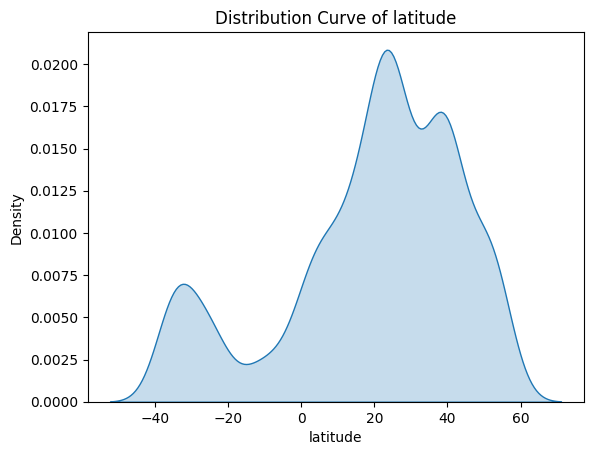

In [25]:
# latitude distn curve and boxplot
sns.kdeplot(disaster['latitude'], fill=True)
plt.title('Distribution Curve of latitude')
plt.show()

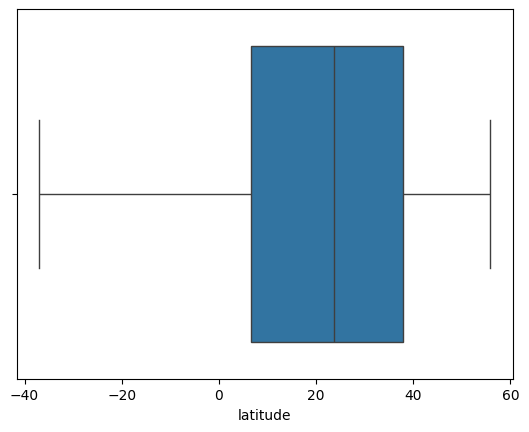

In [26]:
sns.boxplot(x=disaster['latitude'])
plt.show()

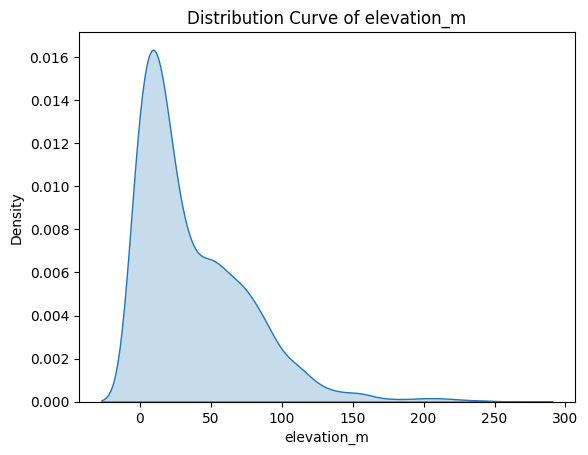

In [27]:
sns.kdeplot(disaster['elevation_m'], fill=True)
plt.title('Distribution Curve of elevation_m')
plt.show() # from here we see it is normal type but have right sqewed data which 

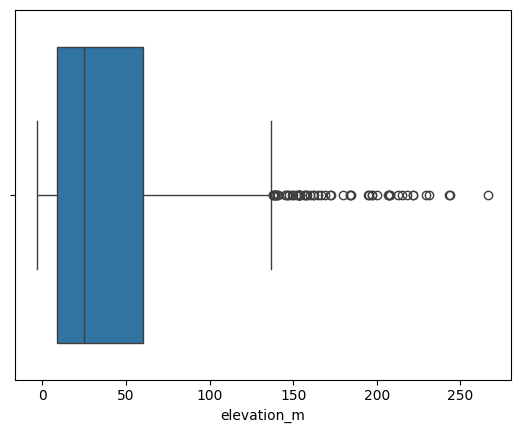

In [28]:
sns.boxplot(x=disaster['elevation_m'])
plt.show()

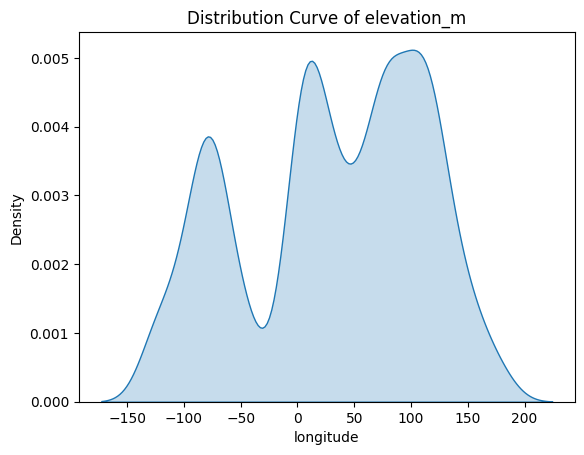

In [29]:
sns.kdeplot(disaster['longitude'], fill=True)
plt.title('Distribution Curve of elevation_m')
plt.show()

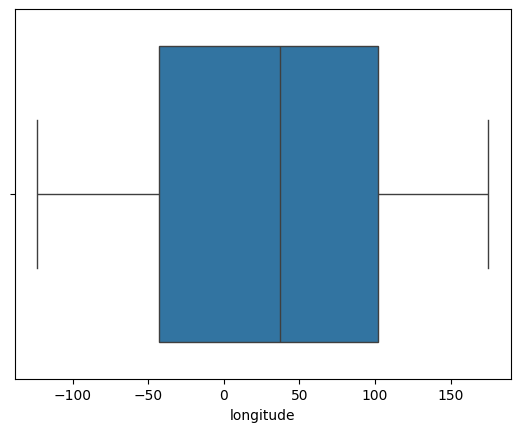

In [30]:
sns.boxplot(x=disaster['longitude'])
plt.show()

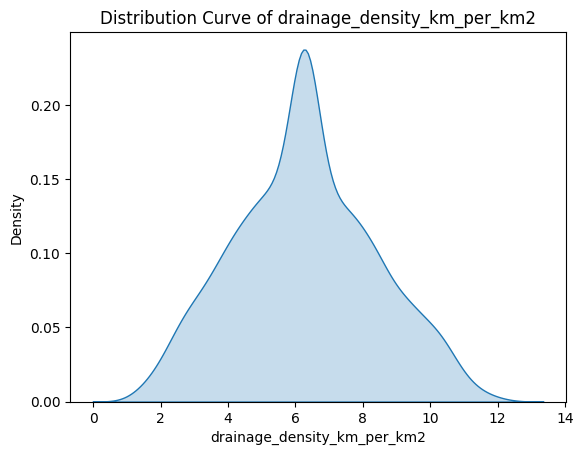

In [31]:
sns.kdeplot(disaster['drainage_density_km_per_km2'], fill=True)
plt.title('Distribution Curve of drainage_density_km_per_km2')
plt.show()

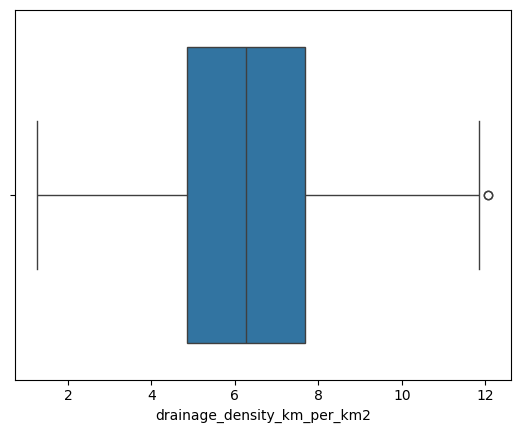

In [32]:
sns.boxplot(x=disaster['drainage_density_km_per_km2'])
plt.show()

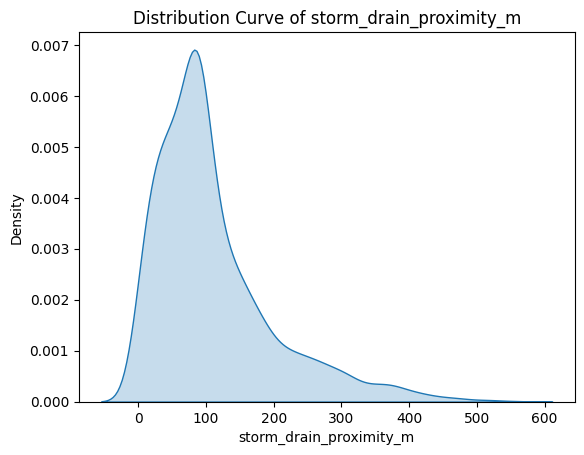

In [33]:
sns.kdeplot(disaster['storm_drain_proximity_m'], fill=True)
plt.title('Distribution Curve of storm_drain_proximity_m')
plt.show()

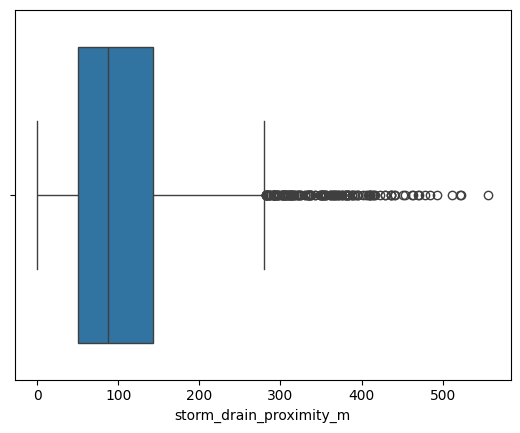

In [34]:
sns.boxplot(x=disaster['storm_drain_proximity_m'])
plt.show()

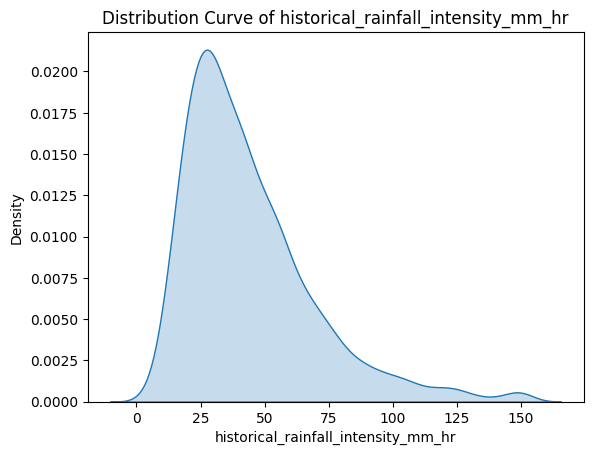

In [35]:
sns.kdeplot(disaster['historical_rainfall_intensity_mm_hr'], fill=True)
plt.title('Distribution Curve of historical_rainfall_intensity_mm_hr')
plt.show()


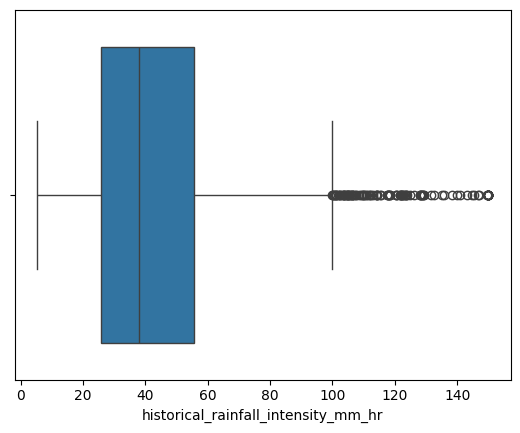

In [36]:
sns.boxplot(x=disaster['historical_rainfall_intensity_mm_hr'])
plt.show()

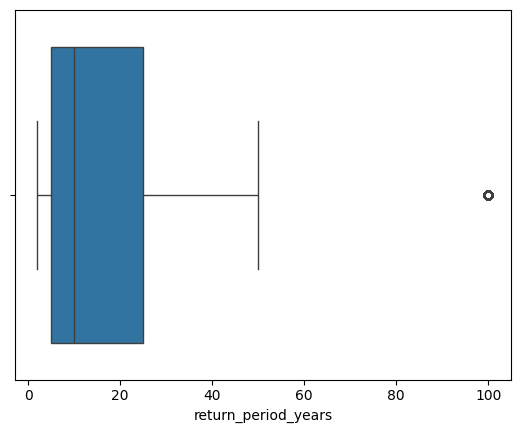

In [37]:
sns.boxplot(x=disaster['return_period_years'])
plt.show()

In [38]:
# colm which have outliers - ['historical_rainfall_intensity_mm_hr-skewed','elevation_m-right skewed','(storm_drain_proximity_m-have right skewed)'] on these 3 colm we  apply capping method 

In [39]:
outlier_cols = ['historical_rainfall_intensity_mm_hr','storm_drain_proximity_m', 'elevation_m']

for col in outlier_cols:
    Q1 = disaster[col].quantile(0.25)
    Q3 = disaster[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    disaster[col] = disaster[col].clip(lower, upper)
    # here clip func work like  a  if else condition 

In [40]:
disaster.describe()

,latitude,longitude,elevation_m,drainage_density_km_per_km2,storm_drain_proximity_m,historical_rainfall_intensity_mm_hr,return_period_years
count,2633.000000,2633.000000,2633.000000,2633.000000,2633.000000,2633.000000,2633.000000
mean,19.322307,31.234303,36.957892,6.282632,105.522807,43.001329,19.747436
std,24.520566,79.702205,35.816360,2.081162,75.742725,22.605712,25.178369
min,-36.999038,-123.292949,-3.000000,1.270000,0.200000,5.400000,2.000000
25%,6.543747,-43.135264,8.770000,4.850000,50.500000,25.900000,5.000000
50%,23.738904,36.834578,24.810000,6.260000,87.500000,38.000000,10.000000
75%,37.871157,101.699500,60.300000,7.680000,142.200000,55.500000,25.000000
max,55.821219,174.911271,137.595000,12.070000,279.750000,99.900000,100.000000


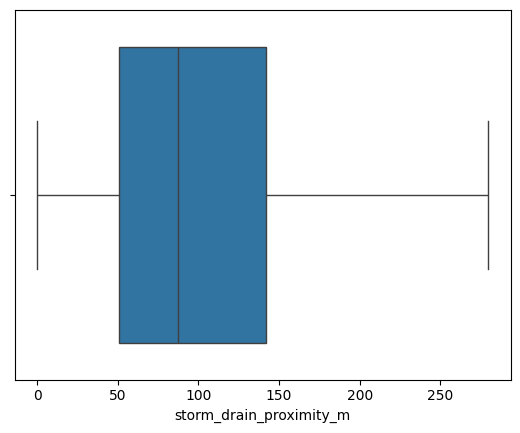

In [41]:
sns.boxplot(x=disaster['storm_drain_proximity_m'])
plt.show()

In [42]:
# overall all outliers handle now 


In [43]:
disaster.head()

,segment_id,city_name,admin_ward,latitude,longitude,catchment_id,elevation_m,dem_source,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,rainfall_source,historical_rainfall_intensity_mm_hr,return_period_years,risk_labels
1,SEG-00002,"Chennai, India",Ward D,13.076487,80.281774,CAT-049,-2.19,Copernicus_EEA-10_v5,Residential,D,7.54,87.50,OpenChannel,ERA5,56.8,25,ponding_hotspot|low_lying|event_2025-05-02
2,SEG-00003,"Ahmedabad, India",Sector 12,23.019473,72.638578,CAT-023,30.88,SRTM_3arc,Industrial,B,11.00,152.50,OpenChannel,IMD,16.3,5,monitor
3,SEG-00004,"Hong Kong, China",Sector 14,22.302602,114.078673,CAT-168,24.28,SRTM_3arc,Residential,B,7.32,37.00,Manhole,ERA5,77.0,10,monitor
4,SEG-00005,"Durban, South Africa",Sector 5,-29.887602,30.911008,CAT-171,35.70,SRTM_3arc,Industrial,C,4.50,279.75,OpenChannel,ERA5,20.8,5,monitor
5,SEG-00006,"Bangkok, Thailand",Borough Harbor,13.730254,100.441634,CAT-132,15.36,Copernicus_GLO-30_v2023,Roads,C,8.97,30.00,Manhole,LocalGauge,99.9,50,extreme_rain_history


In [44]:
def map_risk(label):
    label = label.lower()
    
    # HIGH risk keywords
    if 'ponding_hotspot' in label or 'extreme_rain_history' in label:
        return 2   # High risk
    
    # MEDIUM risk keywords
    elif 'low_lying' in label or 'sparse_drainage' in label:
        return 1   # Medium risk
    
    # LOW risk
    elif 'monitor' in label:
        return 0   # Low risk
    
    else:
        return 0   # default safe

In [45]:
disaster['risk_level'] = disaster['risk_labels'].apply(map_risk)

In [46]:
disaster.head()

,segment_id,city_name,admin_ward,latitude,longitude,catchment_id,elevation_m,dem_source,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,rainfall_source,historical_rainfall_intensity_mm_hr,return_period_years,risk_labels,risk_level
1,SEG-00002,"Chennai, India",Ward D,13.076487,80.281774,CAT-049,-2.19,Copernicus_EEA-10_v5,Residential,D,7.54,87.50,OpenChannel,ERA5,56.8,25,ponding_hotspot|low_lying|event_2025-05-02,2
2,SEG-00003,"Ahmedabad, India",Sector 12,23.019473,72.638578,CAT-023,30.88,SRTM_3arc,Industrial,B,11.00,152.50,OpenChannel,IMD,16.3,5,monitor,0
3,SEG-00004,"Hong Kong, China",Sector 14,22.302602,114.078673,CAT-168,24.28,SRTM_3arc,Residential,B,7.32,37.00,Manhole,ERA5,77.0,10,monitor,0
4,SEG-00005,"Durban, South Africa",Sector 5,-29.887602,30.911008,CAT-171,35.70,SRTM_3arc,Industrial,C,4.50,279.75,OpenChannel,ERA5,20.8,5,monitor,0
5,SEG-00006,"Bangkok, Thailand",Borough Harbor,13.730254,100.441634,CAT-132,15.36,Copernicus_GLO-30_v2023,Roads,C,8.97,30.00,Manhole,LocalGauge,99.9,50,extreme_rain_history,2


In [47]:
disaster.drop(columns=['risk_labels'], inplace=True)

In [48]:
disaster.head()

,segment_id,city_name,admin_ward,latitude,longitude,catchment_id,elevation_m,dem_source,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,rainfall_source,historical_rainfall_intensity_mm_hr,return_period_years,risk_level
1,SEG-00002,"Chennai, India",Ward D,13.076487,80.281774,CAT-049,-2.19,Copernicus_EEA-10_v5,Residential,D,7.54,87.50,OpenChannel,ERA5,56.8,25,2
2,SEG-00003,"Ahmedabad, India",Sector 12,23.019473,72.638578,CAT-023,30.88,SRTM_3arc,Industrial,B,11.00,152.50,OpenChannel,IMD,16.3,5,0
3,SEG-00004,"Hong Kong, China",Sector 14,22.302602,114.078673,CAT-168,24.28,SRTM_3arc,Residential,B,7.32,37.00,Manhole,ERA5,77.0,10,0
4,SEG-00005,"Durban, South Africa",Sector 5,-29.887602,30.911008,CAT-171,35.70,SRTM_3arc,Industrial,C,4.50,279.75,OpenChannel,ERA5,20.8,5,0
5,SEG-00006,"Bangkok, Thailand",Borough Harbor,13.730254,100.441634,CAT-132,15.36,Copernicus_GLO-30_v2023,Roads,C,8.97,30.00,Manhole,LocalGauge,99.9,50,2


In [49]:
#now we convert cagegorical data into numbewricsl  colm - city_name , admin_ward,  catchment_id, dem_source, land_use ,soil group 

In [50]:
# there are two colm id and city_name not use for target colm so we remove it 

In [51]:
disaster = disaster.drop(columns=['segment_id','city_name'])

In [52]:
disaster.head()

,admin_ward,latitude,longitude,catchment_id,elevation_m,dem_source,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,rainfall_source,historical_rainfall_intensity_mm_hr,return_period_years,risk_level
1,Ward D,13.076487,80.281774,CAT-049,-2.19,Copernicus_EEA-10_v5,Residential,D,7.54,87.50,OpenChannel,ERA5,56.8,25,2
2,Sector 12,23.019473,72.638578,CAT-023,30.88,SRTM_3arc,Industrial,B,11.00,152.50,OpenChannel,IMD,16.3,5,0
3,Sector 14,22.302602,114.078673,CAT-168,24.28,SRTM_3arc,Residential,B,7.32,37.00,Manhole,ERA5,77.0,10,0
4,Sector 5,-29.887602,30.911008,CAT-171,35.70,SRTM_3arc,Industrial,C,4.50,279.75,OpenChannel,ERA5,20.8,5,0
5,Borough Harbor,13.730254,100.441634,CAT-132,15.36,Copernicus_GLO-30_v2023,Roads,C,8.97,30.00,Manhole,LocalGauge,99.9,50,2


In [53]:
disaster = disaster.drop(columns=['catchment_id'])

In [54]:
disaster.shape

(2633, 14)

In [55]:
disaster = disaster.drop(columns=['admin_ward'])

In [56]:
disaster = disaster.drop(columns=['dem_source'])

In [57]:
disaster = disaster.drop(columns=['rainfall_source'])

In [58]:
disaster.head()

,latitude,longitude,elevation_m,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,historical_rainfall_intensity_mm_hr,return_period_years,risk_level
1,13.076487,80.281774,-2.19,Residential,D,7.54,87.50,OpenChannel,56.8,25,2
2,23.019473,72.638578,30.88,Industrial,B,11.00,152.50,OpenChannel,16.3,5,0
3,22.302602,114.078673,24.28,Residential,B,7.32,37.00,Manhole,77.0,10,0
4,-29.887602,30.911008,35.70,Industrial,C,4.50,279.75,OpenChannel,20.8,5,0
5,13.730254,100.441634,15.36,Roads,C,8.97,30.00,Manhole,99.9,50,2


In [59]:
X=disaster.drop(columns=['risk_level'])

In [60]:
X.shape

(2633, 10)

In [61]:
y=disaster['risk_level']

In [62]:
from sklearn.model_selection import train_test_split


In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

In [64]:
X_test.shape

(527, 10)

In [65]:
from sklearn.preprocessing import OneHotEncoder

In [66]:
cat_cols = ['land_use', 'soil_group', 'storm_drain_type']
ohe=OneHotEncoder(drop='first', handle_unknown='ignore',sparse_output=False)
X_train_cat = ohe.fit_transform(X_train[cat_cols])
X_test_cat  = ohe.transform(X_test[cat_cols])

In [67]:
X_train_num = X_train.drop(columns=cat_cols).values
X_test_num  = X_test.drop(columns=cat_cols).values

In [68]:
X_train_final = np.hstack((X_train_num, X_train_cat))
X_test_final  = np.hstack((X_test_num, X_test_cat))

In [69]:
final_cols = list(X_train.drop(columns=cat_cols).columns) + \
             list(ohe.get_feature_names_out(cat_cols))

In [70]:
X_train_final = pd.DataFrame(X_train_final, columns=final_cols)
X_test_final  = pd.DataFrame(X_test_final, columns=final_cols)

In [71]:
X_train_final.shape

(2106, 22)

In [72]:
X_test_final.shape

(527, 22)

In [73]:
# NOW WE TRAIN MODEL 

In [74]:
# RANDOM FOREST 

In [75]:
from sklearn.metrics import classification_report

In [76]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=50,random_state=42,max_depth=50,n_jobs=-1,oob_score=True)
rf.fit(X_train_final,y_train)
y_pred1=rf.predict(X_test_final)
print(classification_report(y_test, y_pred1))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       357
           1       0.94      0.99      0.96       117
           2       0.98      0.85      0.91        53

    accuracy                           0.98       527
   macro avg       0.97      0.95      0.96       527
weighted avg       0.98      0.98      0.98       527



In [77]:
# for it we get recall of class 2 - 0.85 and overall recall ( marco) 0.95 and accuracy - 0.98

In [78]:
# now we apply decision tree 

In [79]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=50,min_samples_split=20,min_samples_leaf=10,class_weight='balanced',random_state=42)
dt.fit(X_train_final, y_train)
y_pred2=dt.predict(X_test_final)
print(classification_report(y_test,y_pred2))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       357
           1       0.96      0.92      0.94       117
           2       0.85      0.98      0.91        53

    accuracy                           0.98       527
   macro avg       0.94      0.97      0.95       527
weighted avg       0.98      0.98      0.98       527



In [80]:
# decision tree give good result here we get recall of class 2 - 0.98 , marco recall - 0.97 

In [81]:
# now we apply multiple logistics regression 

In [82]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [83]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled  = scaler.transform(X_test_final)
pca = PCA(n_components=0.90,whiten=False,svd_solver='full',random_state=42)   
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)
np.cumsum(pca.explained_variance_ratio_)


array([0.08427287, 0.15674826, 0.22576558, 0.2885097 , 0.3483438 ,
       0.40680593, 0.4643932 , 0.5194159 , 0.57274706, 0.62253543,
       0.67135284, 0.7187422 , 0.76429527, 0.80965756, 0.85030828,
       0.88497535, 0.91488386])

In [84]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(multi_class='multinomial',solver='lbfgs',class_weight='balanced',max_iter=10,random_state=42)
lr.fit(X_train_pca, y_train)
y_pred_lr = lr.predict(X_test_pca)
print(classification_report(y_test, y_pred_lr))                                               

              precision    recall  f1-score   support

           0       0.92      0.72      0.81       357
           1       0.55      0.79      0.65       117
           2       0.41      0.64      0.50        53

    accuracy                           0.73       527
   macro avg       0.63      0.72      0.65       527
weighted avg       0.79      0.73      0.74       527



C:\Users\sujal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\sujal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [85]:
# now we apply knn 
from sklearn.neighbors import KNeighborsClassifier

In [86]:
knn=KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train_pca, y_train)
y_pred_knn = knn.predict(X_test_pca)
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.73      0.96      0.83       357
           1       0.50      0.14      0.21       117
           2       0.67      0.30      0.42        53

    accuracy                           0.71       527
   macro avg       0.63      0.47      0.49       527
weighted avg       0.67      0.71      0.65       527



In [87]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px

In [88]:
pca = PCA(n_components=3, random_state=42)
X_pca_3d = pca.fit_transform(X_train_scaled)

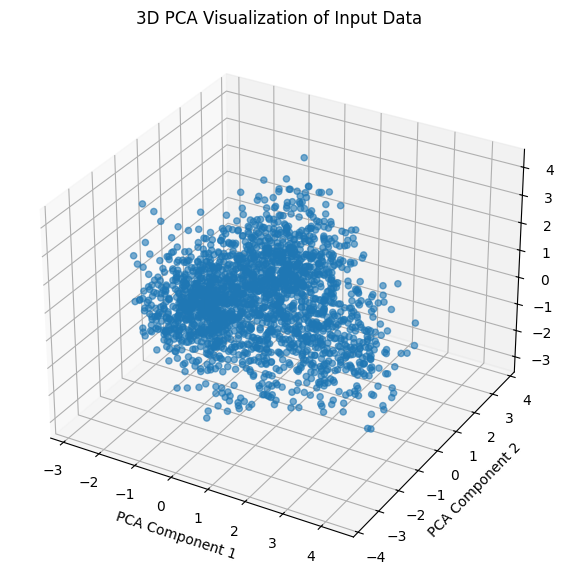

In [89]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_pca_3d[:, 0],
    X_pca_3d[:, 1],
    X_pca_3d[:, 2],
    alpha=0.6
)

ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.set_title('3D PCA Visualization of Input Data')

plt.show()

In [90]:
# now we have do unsupervised learning in it (do cluster k mean model here ) 


In [91]:
X.head(1)

,latitude,longitude,elevation_m,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,historical_rainfall_intensity_mm_hr,return_period_years
1,13.076487,80.281774,-2.19,Residential,D,7.54,87.5,OpenChannel,56.8,25


In [92]:
# now we first transfer whole input data  categorical to numberical 


In [93]:
cat_cols = ['land_use', 'soil_group', 'storm_drain_type']
ohe=OneHotEncoder(drop='first', handle_unknown='ignore',sparse_output=False)
X_cat = ohe.fit_transform(X[cat_cols])
X_num = X.drop(columns=cat_cols).values
X_final = np.hstack((X_num, X_cat))
final_cols = list(X.drop(columns=cat_cols).columns) + \
             list(ohe.get_feature_names_out(cat_cols))
X_final = pd.DataFrame(X_final, columns=final_cols)

In [94]:
X_final.shape

(2633, 22)

In [95]:
# now do scaling then pca 

In [96]:
scaler = StandardScaler()
X_final_scaled = scaler.fit_transform(X_final)
pca = PCA(n_components=0.90,whiten=False,svd_solver='full',random_state=42)   
X_pca = pca.fit_transform(X_final_scaled)
np.cumsum(pca.explained_variance_ratio_)

array([0.08375209, 0.1550596 , 0.22369779, 0.28655126, 0.34739636,
       0.40567661, 0.46232669, 0.51708794, 0.56982471, 0.62000554,
       0.66905076, 0.71649631, 0.76263252, 0.80725679, 0.84883411,
       0.88329295, 0.91369862])

In [97]:
X_pca.head()

AttributeError: 'numpy.ndarray' object has no attribute 'head'

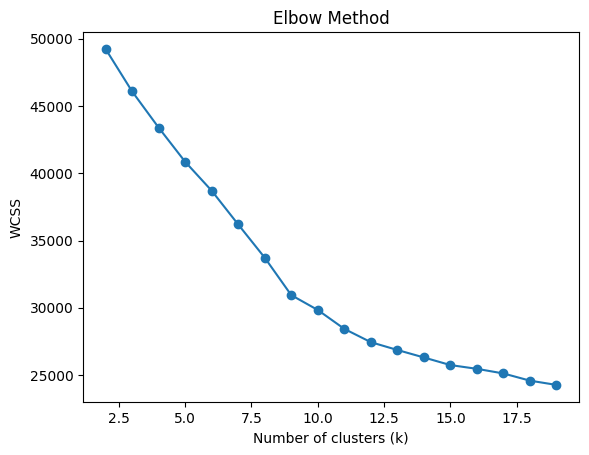

In [98]:
# now we apply k mean model here 
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
K = range(2, 20)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    wcss.append(km.inertia_)

plt.plot(K, wcss, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [99]:
X_pca_df = pd.DataFrame(
    X_pca,
    columns=[f'PC{i+1}' for i in range(X_pca.shape[1])]
)#  use it to convet pca numpy array to data fraame 

In [100]:


kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

X_pca_df['cluster'] = clusters

In [101]:
X_pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,cluster
0,0.727425,-0.301878,1.165465,-1.152913,-0.555661,0.454318,2.865713,-0.750980,0.402140,0.433080,-0.511405,-0.030217,0.486990,0.553496,-0.306558,0.319756,-0.236269,2
1,-0.386056,-2.154930,-0.446990,0.778169,-1.085686,-2.970850,1.540619,1.669124,0.943697,-0.193688,0.071473,-0.635098,-0.266281,-0.207998,-0.249798,0.540565,-0.906723,1
2,-0.797194,1.978849,1.929920,1.460057,0.044834,-0.782295,0.700961,-0.199076,-0.056805,-0.301541,-0.335707,-0.238773,-0.233686,0.409257,-0.340214,0.907925,0.795014,2
3,1.835456,-1.669936,-0.726280,-0.556223,1.662776,-1.592585,1.360927,1.976790,1.053624,0.069625,0.183517,-0.456063,-0.238335,-0.836815,-0.289325,-1.763777,-0.748146,3
4,-1.688652,-1.201784,2.435520,0.795688,2.501387,0.744955,-0.589394,-0.646433,-1.196911,-0.473821,-1.208237,-0.475489,0.267499,0.297251,0.579990,0.072761,0.862249,1


In [102]:
# now we have cluster for each row now we attact cluster row with cleaning data 

In [103]:
X.head()

,latitude,longitude,elevation_m,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,historical_rainfall_intensity_mm_hr,return_period_years
1,13.076487,80.281774,-2.19,Residential,D,7.54,87.50,OpenChannel,56.8,25
2,23.019473,72.638578,30.88,Industrial,B,11.00,152.50,OpenChannel,16.3,5
3,22.302602,114.078673,24.28,Residential,B,7.32,37.00,Manhole,77.0,10
4,-29.887602,30.911008,35.70,Industrial,C,4.50,279.75,OpenChannel,20.8,5
5,13.730254,100.441634,15.36,Roads,C,8.97,30.00,Manhole,99.9,50


In [104]:
X['cluster'] = clusters

In [105]:
X.head()

,latitude,longitude,elevation_m,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,historical_rainfall_intensity_mm_hr,return_period_years,cluster
1,13.076487,80.281774,-2.19,Residential,D,7.54,87.50,OpenChannel,56.8,25,2
2,23.019473,72.638578,30.88,Industrial,B,11.00,152.50,OpenChannel,16.3,5,1
3,22.302602,114.078673,24.28,Residential,B,7.32,37.00,Manhole,77.0,10,2
4,-29.887602,30.911008,35.70,Industrial,C,4.50,279.75,OpenChannel,20.8,5,3
5,13.730254,100.441634,15.36,Roads,C,8.97,30.00,Manhole,99.9,50,1


In [106]:
pd.crosstab(X['cluster'], disaster['risk_level'], normalize='index')

risk_level,0,1,2
cluster,,,
0,0.635417,0.177083,0.187500
1,0.703994,0.160532,0.135474
2,0.639566,0.210027,0.150407
3,0.597701,0.285441,0.116858


In [107]:
X.groupby('cluster')[['historical_rainfall_intensity_mm_hr',
                             'return_period_years']].mean()

,historical_rainfall_intensity_mm_hr,return_period_years
cluster,,
0,43.085417,18.708333
1,42.419499,19.085356
2,43.173035,19.670732
3,44.166475,21.666667


In [108]:
# by these table now we assing cluster 
# Cluster 1 → Low risk zone
# Cluster 0 → Low–Medium risk zone
# Cluster 2 → Medium risk zone
# Cluster 3 → Medium–High risk zone

In [109]:
# now we apply decision tree on data in which we now add one more feature cluster 

In [110]:
X.head(1)

,latitude,longitude,elevation_m,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,historical_rainfall_intensity_mm_hr,return_period_years,cluster
1,13.076487,80.281774,-2.19,Residential,D,7.54,87.5,OpenChannel,56.8,25,2


In [111]:
y.head(20)

1     2
2     0
3     0
4     0
5     2
6     0
7     0
9     0
10    0
11    0
12    1
13    0
14    0
15    0
16    0
17    2
18    2
19    0
21    0
23    0
Name: risk_level, dtype: int64

In [112]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

In [113]:
cat_cols = ['land_use', 'soil_group', 'storm_drain_type']
ohe=OneHotEncoder(drop='first', handle_unknown='ignore',sparse_output=False)
X_train_cat = ohe.fit_transform(X_train[cat_cols])
X_test_cat  = ohe.transform(X_test[cat_cols])
X_train_num = X_train.drop(columns=cat_cols).values
X_test_num  = X_test.drop(columns=cat_cols).values
X_train_final = np.hstack((X_train_num, X_train_cat))
X_test_final  = np.hstack((X_test_num, X_test_cat))
final_cols = list(X_train.drop(columns=cat_cols).columns) + \
             list(ohe.get_feature_names_out(cat_cols))
X_train_final = pd.DataFrame(X_train_final, columns=final_cols)
X_test_final  = pd.DataFrame(X_test_final, columns=final_cols)


In [114]:
X_test_final.head(1)

,latitude,longitude,elevation_m,drainage_density_km_per_km2,storm_drain_proximity_m,historical_rainfall_intensity_mm_hr,return_period_years,cluster,land_use_Green,land_use_Industrial,...,land_use_Residential,land_use_Roads,land_use_Water,soil_group_B,soil_group_C,soil_group_D,soil_group_missing,storm_drain_type_GratedInlet,storm_drain_type_Manhole,storm_drain_type_OpenChannel
0,28.667313,77.171789,3.61,7.72,31.3,27.7,25.0,3.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [115]:
# now apply decision tree 
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=50,min_samples_split=20,min_samples_leaf=10,class_weight='balanced',random_state=42)
dt.fit(X_train_final, y_train)
y_pred2=dt.predict(X_test_final)
print(classification_report(y_test,y_pred2))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       357
           1       0.93      0.92      0.93       117
           2       0.84      0.91      0.87        53

    accuracy                           0.97       527
   macro avg       0.92      0.94      0.93       527
weighted avg       0.97      0.97      0.97       527



In [116]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=50,random_state=42,max_depth=50,n_jobs=-1,oob_score=True)
rf.fit(X_train_final,y_train)
y_pred1=rf.predict(X_test_final)
print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       357
           1       0.92      1.00      0.96       117
           2       1.00      0.85      0.92        53

    accuracy                           0.98       527
   macro avg       0.97      0.95      0.96       527
weighted avg       0.98      0.98      0.98       527



In [117]:
# not get benifit with unsuperivesd learning so noow at last we go with decision tree only with superivesd learning 

In [118]:
X = X.drop(columns=['cluster'])

In [119]:
X.head()

,latitude,longitude,elevation_m,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,historical_rainfall_intensity_mm_hr,return_period_years
1,13.076487,80.281774,-2.19,Residential,D,7.54,87.50,OpenChannel,56.8,25
2,23.019473,72.638578,30.88,Industrial,B,11.00,152.50,OpenChannel,16.3,5
3,22.302602,114.078673,24.28,Residential,B,7.32,37.00,Manhole,77.0,10
4,-29.887602,30.911008,35.70,Industrial,C,4.50,279.75,OpenChannel,20.8,5
5,13.730254,100.441634,15.36,Roads,C,8.97,30.00,Manhole,99.9,50


In [120]:
X.shape

(2633, 10)

In [121]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [122]:
cat_cols = ['land_use', 'soil_group', 'storm_drain_type']
num_cols = [col for col in X.columns if col not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', DecisionTreeClassifier(
        max_depth=50,min_samples_split=20,min_samples_leaf=10,class_weight='balanced',random_state=42
    ))
])

In [123]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [124]:
import pickle

pickle.dump(pipeline, open('disaster_risk_pipeline.pkl', 'wb'))

In [125]:
model = pickle.load(open('disaster_risk_pipeline.pkl', 'rb'))


In [126]:
X.head(1)

,latitude,longitude,elevation_m,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,historical_rainfall_intensity_mm_hr,return_period_years
1,13.076487,80.281774,-2.19,Residential,D,7.54,87.5,OpenChannel,56.8,25


In [127]:
new_input = pd.DataFrame([{
    'latitude': 13.076487,
    'longitude': 80.281774,
    'elevation_m': -2.19,
    'land_use': 'Residential',
    'soil_group': 'D',
    'drainage_density_km_per_km2': 7.54,
    'storm_drain_proximity_m': 87.5,
    'storm_drain_type': 'OpenChannel',
    'historical_rainfall_intensity_mm_hr': 100.8,
    'return_period_years': 25
}])

In [128]:
model.predict(new_input)  # 2- high risk , 1- medium risk , 0 - low risk 

array([2])